# Exporting a jeanie halo to galpy, agama or galax

A solved halo is a set of callables — `rho(R,z)`, `M(<r)`, `g_r(r)`, `Phi(r)`.
Each orbit library wants a different one of them, in different units, and
getting the units wrong is **silent**: a mis-scaled potential still integrates
orbits, it just integrates the wrong ones. `jeanie.export` does those
conversions in one place, and every number quoted in this notebook is asserted
in `tests/test_export.py` and `tests/test_multipole.py`.

Three things to know before using any of it.

**Baryons.** `mass_fn`, `radial_acceleration_fn` and `potential_fn` are *dark
matter only* — the baryons shape the halo through `Phi_b` but are not added to
it. For an orbit you want the total, so `baryons=True` is the default
everywhere here. The tell for having got this wrong is that an orbit outside
`r1` has exactly zero gradient with respect to `Md`, `a` and `b`.

**Shape.** The halo is flattened inside `r1`, by the disc, with a gradient:
q = 0.62 at 3 kpc rising to 0.93 at 14 kpc. Any export that reduces it to a
function of `r` throws that away. The default galpy route is
`MultipoleExpansionPotential`, **new in galpy 1.12** — on 1.11 the only basis
expansion was SCF, which does not converge on this profile at any order, and
`kind="multipole-ref"` is the fallback there.

**G.** jeanie solves with `G = 4.302e-6`; agama and galax both use CODATA,
`4.30091727e-6`. The difference is 2.5e-4 and it is systematic. Each exporter
handles it explicitly, and the section for each one says how.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jeanie.export import callables, multipole, to_galpy, to_agama, to_galax

# [M200, c, r1, Md, a, b]  -- Msun, dimensionless, kpc, Msun, kpc, kpc
params = np.array([1.0e12, 10.0, 15.0, 6.0e10, 3.0, 0.28])
r1 = params[2]
fns = callables(params)
print({k: type(v).__name__ for k, v in fns.items()})

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


{'rho': 'function', 'M': 'function', 'g': 'function', 'Phi': 'function'}


## The framework-agnostic export

`callables()` is the escape hatch: four plain JAX functions, differentiable in
the halo parameters. If your framework is not one of the three below, wrapping
these is less work than fighting a converter.

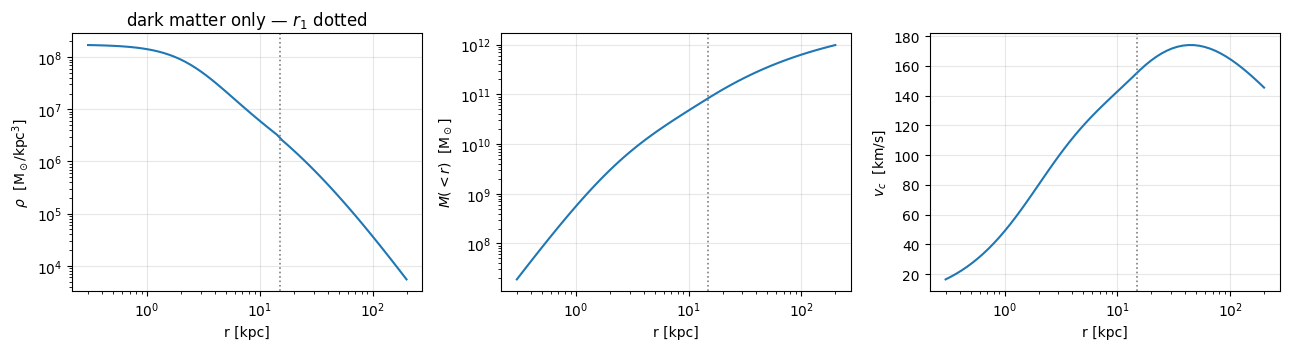

In [2]:
r = np.geomspace(0.3, 200.0, 60)
rho = np.array([float(fns["rho"](x, 0.0)) for x in r])
M   = np.array([float(fns["M"](x)) for x in r])
vc  = np.sqrt(4.302e-6 * M / r)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].loglog(r, rho); ax[0].set(xlabel="r [kpc]", ylabel=r"$\rho$  [M$_\odot$/kpc$^3$]")
ax[1].loglog(r, M);   ax[1].set(xlabel="r [kpc]", ylabel=r"$M(<r)$  [M$_\odot$]")
ax[2].semilogx(r, vc); ax[2].set(xlabel="r [kpc]", ylabel=r"$v_c$  [km/s]")
for a_ in ax: a_.axvline(r1, color="grey", ls=":", lw=1.2); a_.grid(alpha=.3)
ax[0].set_title("dark matter only — $r_1$ dotted")
fig.tight_layout()

## The halo is not spherical

Inside `r1` the isothermal solution carries `exp(-Phi_b/sigma0^2)`, so the disc
squashes it; outside, the CDM profile takes over and is spherical unless `q0`
is set. The density is therefore *discontinuous in angle* at `r1` — that is a
property of the model, not of any expansion of it, and it is the single fact
that decides which exports work.

`multipole()` returns the expansion itself, independent of any library.

q(3 kpc) = 0.619   q(14 kpc) = 0.934


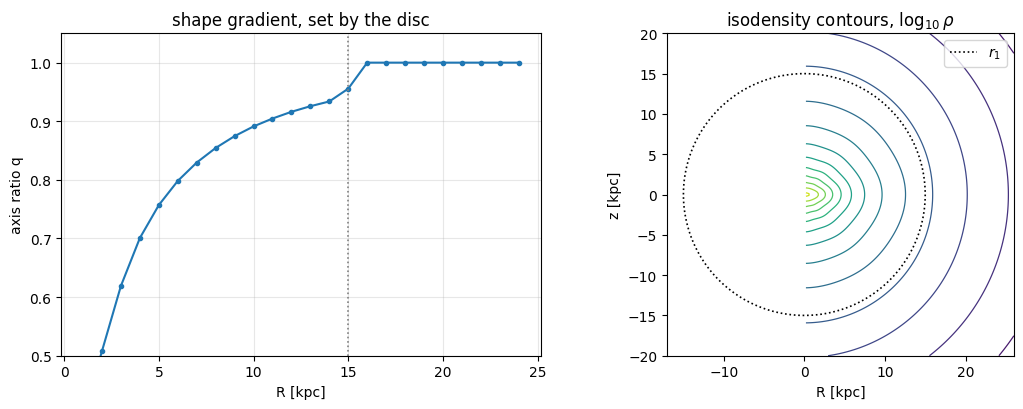

In [3]:
from scipy.optimize import brentq

exp = multipole(params, lmax=8)          # a node pinned on the break at r1

def axis_ratio(e, R):
    # z at which the density equals its midplane value at R, over R
    target = float(e.density(R, 0.0))
    return brentq(lambda zz: float(e.density(0.0, zz)) - target, 0.05*R, 4.0*R) / R

Rq = np.linspace(1.0, 24.0, 24)
q  = np.array([axis_ratio(exp, x) for x in Rq])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(Rq, q, "o-", ms=3)
ax[0].axvline(r1, color="grey", ls=":", lw=1.2)
ax[0].set(xlabel="R [kpc]", ylabel="axis ratio q", ylim=(0.5, 1.05),
          title="shape gradient, set by the disc")
ax[0].grid(alpha=.3)

Rg = np.linspace(0.2, 26, 200); Zg = np.linspace(-20, 20, 200)
RR, ZZ = np.meshgrid(Rg, Zg)
D = np.log10(np.abs(exp.density(RR, ZZ)))
cs = ax[1].contour(RR, ZZ, D, levels=12, linewidths=.9)
th = np.linspace(0, 2*np.pi, 200)
ax[1].plot(r1*np.sin(th), r1*np.cos(th), "k:", lw=1.2, label="$r_1$")
ax[1].set(xlabel="R [kpc]", ylabel="z [kpc]", aspect="equal",
          title=r"isodensity contours, $\log_{10}\rho$")
ax[1].legend(loc="upper right")
fig.tight_layout()
print("q(3 kpc) = %.3f   q(14 kpc) = %.3f" % (axis_ratio(exp, 3.0), axis_ratio(exp, 14.0)))

## galpy

`MultipoleExpansionPotential.from_density` arrived in galpy 1.12 and is what
`to_galpy` uses by default. It is C-backed, so an orbit integrates in C even
though the density that built it is a JAX function in Python.

| `kind` | keeps shape | density error | orbit, 3 Gyr |
|---|---|---|---|
| `"multipole"` (default, galpy ≥ 1.12) | yes | 2.1e-4 median, 3.0e-2 worst | 0.05 s, dE/\|E\| = 3e-14 |
| `"multipole-ref"` (jeanie's own) | yes | 2.5e-4 median, 2.9e-2 worst | 1.16 s — pure Python, no C integrator |
| `"spherical"` | **no** | 2.6e-2 median, 3.4e-1 worst — it *is* the monopole | fastest |
| `"scf"` (what 1.11 had) | yes | 40% at (N,L)=(8,6), 28% at (20,10) | — |

Those errors are |ρ_expansion/ρ_input − 1| on one fixed grid: 40 log-spaced
radii from 0.5 to 300 kpc crossed with cos θ ∈ {0, 0.3, 0.6, 0.9}. Quoting a
median over points chosen afterwards says more about the points than about the
expansion, so the table further down — which uses eight hand-picked points to
show *where* each one fails — gives different numbers on purpose.

Two notes on the default path, both learned the hard way:

* **Do not pin grid nodes either side of `r1`.** Straddling the density jump
  is worth four orders of magnitude for a quadrature scheme like
  `multipole-ref`, and it takes galpy's density error to **2e+2**, because
  galpy splines the radial coefficients and two nodes a part in 1e9 apart are
  not something a spline can fit. Use a denser log grid instead (`n_r`).
* **galpy calls the density one scalar at a time**, 800 × 20 times for the
  default grid. Against a JAX function at ~5 ms a call that is 88 s per halo.
  `jeanie.export` precomputes exactly those points in one vectorised call and
  serves them from a table, which is bit-identical and takes 12 s.

In [4]:
import time
import galpy.potential as gp
import galpy

print("galpy", galpy.__version__,
      "— has MultipoleExpansionPotential:", hasattr(gp, "MultipoleExpansionPotential"))

ro, vo = 8.0, 220.0
F0, P0 = vo**2/ro, vo**2
D0 = (vo**2 * ro / 4.302e-6) / ro**3

t0 = time.time()
pot_dm = to_galpy(params, ro=ro, vo=vo, kind="multipole", baryons=False)
print(f"built the native multipole in {time.time()-t0:.1f} s  (hasC={pot_dm.hasC})")

t0 = time.time()
ref_dm = to_galpy(params, ro=ro, vo=vo, kind="multipole-ref", baryons=False)
print(f"built jeanie's own reference expansion in {time.time()-t0:.1f} s")

# the strongest check available: two independent expansions, a spline scheme
# and a quadrature scheme, on the same density
print(f"\n{'(R,z) kpc':>14s} {'F_R galpy/jeanie':>18s} {'Phi offset':>12s}")
for R, z in [(1.,0.), (5.,2.), (10.,4.), (15.5,0.), (60.,30.), (200.,0.)]:
    fg = float(gp.evaluateRforces(pot_dm, R/ro, z/ro, use_physical=False))*F0
    fr = float(gp.evaluateRforces(ref_dm, R/ro, z/ro, use_physical=False))*F0
    pg = float(gp.evaluatePotentials(pot_dm, R/ro, z/ro, use_physical=False))*P0
    pr = float(gp.evaluatePotentials(ref_dm, R/ro, z/ro, use_physical=False))*P0
    print(f"  ({R:6.1f},{z:5.1f}) {fg/fr:18.9f} {pg-pr:12.1f}")
print("\nThe Phi offset is constant: galpy sets the density to zero beyond rmax,")
print("jeanie extrapolates a power law, and for an Einasto envelope that is")
print("~1e11 Msun past 900 kpc. No force and no orbit sees it; an energy does.")

galpy 1.12.0 — has MultipoleExpansionPotential: True


built the native multipole in 4.1 s  (hasC=True)


built jeanie's own reference expansion in 0.3 s

     (R,z) kpc   F_R galpy/jeanie   Phi offset
  (   1.0,  0.0)        1.000163303       3222.9
  (   5.0,  2.0)        0.999977360       3222.2
  (  10.0,  4.0)        0.999878415       3219.7
  (  15.5,  0.0)        0.999661959       3218.9
  (  60.0, 30.0)        0.999966282       3214.5
  ( 200.0,  0.0)        0.999984286       3213.8

The Phi offset is constant: galpy sets the density to zero beyond rmax,
jeanie extrapolates a power law, and for an Einasto envelope that is
~1e11 Msun past 900 kpc. No force and no orbit sees it; an energy does.


### An orbit, and whether it conserves energy

The multipole's forces are the exact derivative of its own Hermite
interpolant, not a second interpolant through the node derivatives. That is
what keeps energy conserved — a potential whose forces are only *approximately*
its own gradient leaks energy, and the leak looks like physics.

3 Gyr, 2000 steps in 0.04 s    dE/|E| = 3.12e-14


same orbit through the pure-Python reference: 1.16 s  (31x)


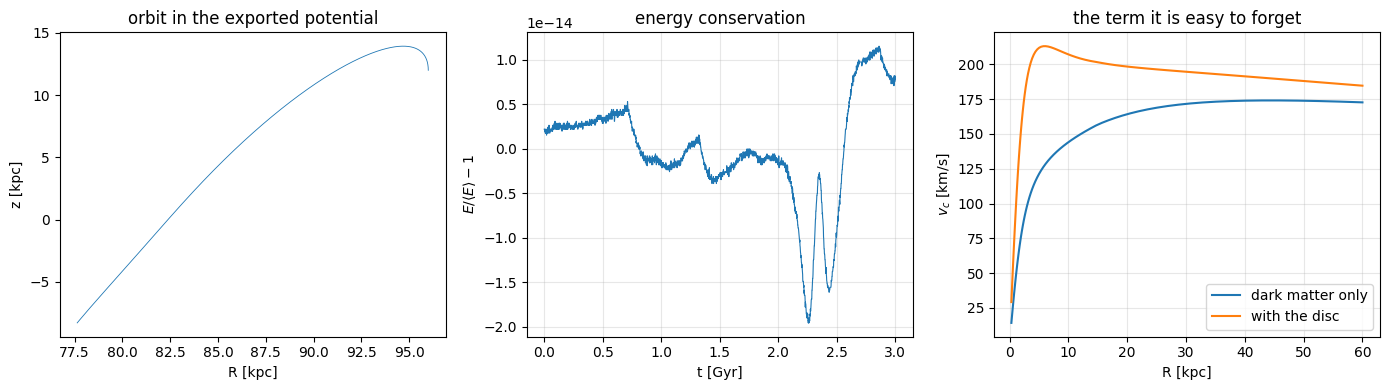

In [5]:
from galpy.orbit import Orbit

pot = to_galpy(params, ro=ro, vo=vo, kind="multipole", baryons=True)
o = Orbit([12.0/ro, 0.0, 180.0/vo, 1.5/ro, 20.0/vo, 0.0], ro=ro, vo=vo)
ts = np.linspace(0.0, 3.0, 2000) * 1.0227          # 3 Gyr in galpy time units
t0 = time.time(); o.integrate(ts, pot); dt = time.time() - t0
E = o.E(ts, pot=pot, use_physical=False)
print(f"3 Gyr, 2000 steps in {dt:.2f} s    dE/|E| = {np.ptp(E)/abs(np.mean(E)):.2e}")

pot_ref = to_galpy(params, ro=ro, vo=vo, kind="multipole-ref", baryons=True)
o2 = Orbit([12.0/ro, 0.0, 180.0/vo, 1.5/ro, 20.0/vo, 0.0], ro=ro, vo=vo)
t0 = time.time(); o2.integrate(ts, pot_ref); dt2 = time.time() - t0
print(f"same orbit through the pure-Python reference: {dt2:.2f} s  ({dt2/dt:.0f}x)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(o.R(ts)*ro, o.z(ts)*ro, lw=.6)
ax[0].set(xlabel="R [kpc]", ylabel="z [kpc]", title="orbit in the exported potential")
ax[1].plot(ts/1.0227, E/np.mean(E) - 1.0, lw=.8)
ax[1].set(xlabel="t [Gyr]", ylabel=r"$E/\langle E\rangle - 1$", title="energy conservation")
rr = np.geomspace(0.3, 60, 80)
for p_, lab in [(pot_dm, "dark matter only"), (pot, "with the disc")]:
    v = np.array([np.sqrt(-float(gp.evaluateRforces(p_, x/ro, 0., use_physical=False))*F0*x) for x in rr])
    ax[2].plot(rr, v, label=lab)
ax[2].set(xlabel="R [kpc]", ylabel=r"$v_c$ [km/s]", title="the term it is easy to forget")
ax[2].legend()
for a_ in ax[1:]: a_.grid(alpha=.3)
fig.tight_layout()

### What the other routes cost

`kind="spherical"` is exact on the monopole and reports q = 1 everywhere.
`kind="scf"` — galpy 1.11's only basis expansion, and the reason this notebook
originally had no working flattened galpy export — keeps the angular freedom
but cannot represent the kink at `r1`. The fault is the basis, not the
plumbing: the identical call reproduces a Hernquist density to 1e-15.

In [6]:
import warnings

pts = [(1.,0.), (3.,2.), (5.,0.), (10.,4.), (14.5,0.), (20.,10.), (60.,30.), (150.,0.)]
ref_rho = np.array([float(fns["rho"](R, z)) for R, z in pts])

nat  = np.array([float(gp.evaluateDensities(pot_dm, R/ro, z/ro, use_physical=False))*D0
                 for R, z in pts])
mp8  = np.array([float(exp.density(R, z)) for R, z in pts])
sph  = np.array([float(multipole(params, lmax=0).density(R, z)) for R, z in pts])
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scf_pot = to_galpy(params, ro=ro, vo=vo, kind="scf", baryons=False, N=8, L=6)
scf = np.array([float(gp.evaluateDensities(scf_pot, R/ro, z/ro, use_physical=False))*D0
                for R, z in pts])

print(f"{'(R,z)':>14s} {'galpy 1.12':>11s} {'jeanie ref':>11s} {'monopole':>11s} {'SCF (8,6)':>11s}")
for (R, z), a, b, c, d in zip(pts, nat/ref_rho-1, mp8/ref_rho-1, sph/ref_rho-1, scf/ref_rho-1):
    print(f"  ({R:6.1f},{z:5.1f}) {a:+11.2e} {b:+11.2e} {c:+11.2e} {d:+11.2e}")
print(f"\n{'median |err|':>14s} {np.median(abs(nat/ref_rho-1)):11.2e} "
      f"{np.median(abs(mp8/ref_rho-1)):11.2e} {np.median(abs(sph/ref_rho-1)):11.2e} "
      f"{np.median(abs(scf/ref_rho-1)):11.2e}")

/geir_data/scr/gabrielspace/.venv/lib/python3.12/site-packages/galpy/potential/SCFPotential.py:662: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))

         (R,z)  galpy 1.12  jeanie ref    monopole   SCF (8,6)
  (   1.0,  0.0)   -3.57e-03   -3.61e-03   -1.86e-01   +1.43e+00
  (   3.0,  2.0)   -1.22e-02   -1.23e-02   +7.24e-02   -9.82e-01
  (   5.0,  0.0)   -2.85e-02   -2.68e-02   -2.15e-01   -5.43e-01
  (  10.0,  4.0)   -2.19e-05   -2.55e-05   -1.76e-02   +4.13e-01
  (  14.5,  0.0)   -8.67e-03   -7.31e-03   -5.62e-02   -3.56e-01
  (  20.0, 10.0)   -7.05e-09   +1.66e-05   +1.66e-05   -2.38e-01
  (  60.0, 30.0)   -1.68e-08   +1.75e-04   +1.75e-04   -2.51e-01
  ( 150.0,  0.0)   -4.75e-09   +2.81e-05   +2.81e-05   +5.73e-03

  median |err|    1.80e-03    1.89e-03    3.69e-02    3.85e-01


## agama

agama's `Multipole` takes the density callable directly, so there is no basis
to fight. Two caveats:

**Global units.** `to_agama` calls `agama.setUnits(Msun, kpc, km/s)`, which
affects every other agama object in the session. That is agama's design, and
it is the usual cause of silently wrong results when mixing sources.

**G.** agama applies CODATA to jeanie's densities, so everything it returns —
halo and disc alike — is uniformly 2.5e-4 away from jeanie. That is the
self-consistent choice, and it is almost the entire difference seen below.

On the fixed grid above, agama at its defaults is 1.3e-3 median against
jeanie's 2.5e-4 — about 5× behind — and at `lmax=12, gridsize=40` it reaches
2.3e-4, i.e. the same place. So this is a defaults difference, not a
capability one; raise both if the shape is the measurement. The forces, which
is what an orbit actually sees, agree to ~2e-4 either way — that is the G
ratio and essentially nothing else.

In [7]:
pot_ag = to_agama(params, baryons=False)
X = np.array([[R, 0.0, z] for R, z in pts])
d_ag = pot_ag.density(X)
f_ag = pot_ag.force(X)

print(f"{'(R,z)':>14s} {'rho agama':>11s} {'rho jeanie-mp':>14s} | {'F_R agama/mp':>13s} {'Phi diff':>10s}")
for (R, z), da, fa in zip(pts, d_ag, f_ag):
    FR = float(exp.forces(R, z)[0])
    dphi = float(exp.potential(R, z)) - pot_ag.potential([[R, 0.0, z]])[0]
    print(f"  ({R:6.1f},{z:5.1f}) {da/float(fns['rho'](R,z))-1:+11.2e} "
          f"{float(exp.density(R,z))/float(fns['rho'](R,z))-1:+14.2e} | "
          f"{fa[0]/FR-1:+13.2e} {dphi:10.1f}")
print("\nmedian |rho err|:  agama %.2e   jeanie multipole %.2e"
      % (np.median(abs(d_ag/np.array([float(fns['rho'](R,z)) for R,z in pts])-1)),
         np.median(abs(mp8/ref_rho-1))))
print("G ratio CODATA/jeanie - 1 = %.2e   <- the size of the force disagreement"
      % (4.30091727e-6/4.302e-6 - 1))

         (R,z)   rho agama  rho jeanie-mp |  F_R agama/mp   Phi diff
  (   1.0,  0.0)   -3.48e-03      -3.61e-03 |     -6.37e-04      -80.7
  (   3.0,  2.0)   -1.33e-02      -1.23e-02 |     +2.30e-05      -81.3
  (   5.0,  0.0)   -2.20e-02      -2.68e-02 |     +2.93e-04      -75.6
  (  10.0,  4.0)   -1.15e-03      -2.55e-05 |     +2.16e-05      -85.9
  (  14.5,  0.0)   -2.46e-02      -7.31e-03 |     +9.71e-04      -89.3
  (  20.0, 10.0)   -2.06e-03      +1.66e-05 |     +1.31e-04      -90.2
  (  60.0, 30.0)   +3.24e-05      +1.75e-04 |     -1.54e-04      -87.6
  ( 150.0,  0.0)   +2.29e-06      +2.81e-05 |     -1.98e-04      -83.8

median |rho err|:  agama 2.77e-03   jeanie multipole 1.89e-03
G ratio CODATA/jeanie - 1 = -2.52e-04   <- the size of the force disagreement


## galax

The reason to export to galax rather than galpy is **end-to-end
differentiability**: the `Phi` it wraps is the same traced JAX function
`jaxprofile` produces, so `d(anything)/d(halo parameters)` works without finite
differences.

Two things this export has to get right, and the first one bit during
development:

**Units.** galax's `"galactic"` system measures speed in **kpc/Myr**, not km/s.
Handing it jeanie's `(km/s)^2` potential unconverted leaves the halo a factor
9.56e5 too shallow beside a disc built by galax — and the composite still
integrates orbits perfectly happily, around the disc. The conversion is taken
from the unit system passed in, not hard-coded.

**G.** The halo was solved with jeanie's G. galax's own
`MiyamotoNagaiPotential` would use CODATA and sit 2.5e-4 deeper, so the disc
here is jeanie's analytic Miyamoto–Nagai instead, carrying the same G as the
halo. A mismatch *between two components of one potential* is worse than a
uniform offset from CODATA, and relabelling `m_tot` by 1.000252 to paper over
it would be worse still.

**Spherically averaged.** `potential_fn` is a function of `r` alone, so this
export carries the monopole only. The flattening lives in the multipole, which
is built with scipy and is therefore not differentiable in the halo parameters.
Shape (galpy, agama) or gradients (galax) — not yet both.

In [8]:
import jax, jax.numpy as jnp

KMS2 = 1.0459401725324528e-06          # (km/s)^2 expressed in (kpc/Myr)^2
dm_gx  = to_galax(params, baryons=False)
tot_gx = to_galax(params, baryons=True)
print(type(tot_gx).__name__, "->", list(tot_gx.keys()))

Md, a_, b_ = params[3], params[4], params[5]
print(f"\n{'r [kpc]':>8s} {'halo/jeanie':>13s} {'disc/analytic':>15s}")
for x in (5.0, 20.0, 60.0):
    q3 = jnp.array([x, 0.0, 0.0])
    halo = float(dm_gx.potential(q3, 0.0))
    disc = float(tot_gx.potential(q3, 0.0)) - halo
    exact = -4.302e-6*Md/np.sqrt(x**2 + (a_+b_)**2) * KMS2
    print(f"{x:8.1f} {halo/(float(fns['Phi'](x))*KMS2):13.10f} {disc/exact:15.10f}")

def phi_of_params(p):
    return to_galax(p, baryons=True).potential(jnp.array([20.0, 0.0, 5.0]), 0.0)

g = np.asarray(jax.grad(phi_of_params)(jnp.asarray(params)))
print("\nd Phi(R=20, z=5) / d param, straight through the galax potential:")
for n, gi in zip(["M200", "c", "r1", "Md", "a", "b"], g):
    print(f"   {n:5s} {gi:+.4e}")
print("\nMd, a, b are non-zero -- the baryons are in there. A zero on those")
print("three is the signature of the baryon trap described at the top.")

CompositePotential -> ['halo', 'disc']

 r [kpc]   halo/jeanie   disc/analytic


     5.0  1.0000000000    1.0000000000
    20.0  1.0000000000    1.0000000000
    60.0  1.0000000000    1.0000000000



d Phi(R=20, z=5) / d param, straight through the galax potential:
   M200  -7.3255e-14
   c     -1.8968e-03
   r1    -2.5449e-04
   Md    -2.0886e-13
   a     +2.1622e-04
   b     +1.2089e-05

Md, a, b are non-zero -- the baryons are in there. A zero on those
three is the signature of the baryon trap described at the top.


## Which one to use

| | shape | differentiable | G | notes |
|---|---|---|---|---|
| `to_galpy(kind="multipole")` | yes | no | jeanie's, exact | the default; galpy ≥ 1.12, C-backed orbits |
| `to_galpy(kind="multipole-ref")` | yes | no | jeanie's, exact | no galpy feature needed; the independent check |
| `to_galpy(kind="spherical")` | no | no | jeanie's, exact | cheapest, monopole only |
| `to_agama` | yes | no | CODATA throughout | global unit state; C++, fast; raise `lmax`/`gridsize` |
| `to_galax` | monopole only | **yes** | jeanie's, exact | the only route to `d(orbit)/d(params)` |
| `callables` | — | yes | jeanie's | wrap it yourself |

Installation: `pip install -e ".[galpy]"` (galpy ≥ 1.12), `".[agama]"`. galax's
PyPI releases are years behind its repository and the current one does not
resolve, so galax is installed from source — see `pyproject.toml`.